In [7]:
# %%
import pandas as pd 
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score, precision_score, recall_score



pd.set_option('display.precision', 15)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 300)


In [8]:
# %%
import warnings
warnings.filterwarnings('ignore')


In [9]:
# %%
#функция для отображения гистограмм всех признаков для целевого поля
def feat_hist(x, group_col, key_cols):
    x_new = x.copy()
    x_new[key_cols] = df[key_cols]
    for c in key_cols:
        for cl in x[group_col].unique():
            #sns.histplot(...)
            sns.distplot(x_new[x_new[group_col]==cl][c], 
                         label='{} = {}'.format(group_col, str(cl)), bins = 10)
        plt.title(c)
        plt.legend()
        plt.show()


In [10]:
# %%



 # Загружаем данные

In [11]:
# %%
df = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')
df.head()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470422861144,5.0,3,0.020397947620858,0.000000000000000,0
1,0,1,0,0,1,12,1,31,113.202937651058207,12.0,7,1.922936055041820,1.910243521519641,0
2,0,1,1,0,1,1,0,28,129.448479332006144,1.0,2,1.859098347383238,1.736501891634414,0
3,0,1,1,1,1,12,1,33,62.669863191238292,12.0,2,3.205632768238500,3.357214513052662,0
4,1,1,1,1,1,1,0,26,198.362265439036833,1.0,3,1.113884400425780,1.120078107422207,0


In [12]:
# %%
df.columns


Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')

In [13]:
# %%
df.shape


(4000, 14)

In [14]:
# %%
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [15]:
# %%
df.describe()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.00000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000
mean,0.510250000000000,0.845250000000000,0.486750000000000,0.308500000000000,0.903500000000000,4.681250000000000,0.412250000000000,29.184249999999999,146.943727809250021,4.322750000000000,3.72475000000000,1.879019712534937,1.767051822040508,0.265250000000000
std,0.499957425044109,0.361711412989097,0.499886896434881,0.461931916275353,0.295312634995682,4.549705857893457,0.492301256987948,3.258367102790019,96.355602395679895,4.191297434094206,3.74926682004919,0.972244872030618,1.052905717489530,0.441521429596802
min,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,18.000000000000000,0.148204788456624,1.000000000000000,0.00000000000000,0.000000000000000,0.000000000000000,0.000000000000000
25%,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,1.000000000000000,0.000000000000000,27.000000000000000,68.868829978416670,1.000000000000000,1.00000000000000,1.180875086219582,0.963002948193214,0.000000000000000
50%,1.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,1.000000000000000,0.000000000000000,29.000000000000000,136.220158971036881,1.000000000000000,3.00000000000000,1.832768412113406,1.719574310109868,0.000000000000000
75%,1.000000000000000,1.000000000000000,1.000000000000000,1.000000000000000,1.000000000000000,6.000000000000000,1.000000000000000,31.000000000000000,210.949624655502134,6.000000000000000,5.00000000000000,2.536078338329289,2.510336265936281,1.000000000000000
max,1.000000000000000,1.000000000000000,1.000000000000000,1.000000000000000,1.000000000000000,12.000000000000000,1.000000000000000,41.000000000000000,552.590740386879816,12.000000000000000,31.00000000000000,6.023668475995910,6.146782880452392,1.000000000000000


In [16]:
# %%
df.groupby('Churn').mean()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037427696495,0.873086083701939,0.534195304525349,0.353521605988431,0.903708744470908,5.747192922762845,0.464103436543042,29.976522626743790,158.445714801611530,5.283089486219803,4.711806736985369,2.024875642518551,2.027881733095180
1,0.510838831291235,0.768143261074458,0.355325164938737,0.183788878416588,0.902921771913289,1.728557964184731,0.268614514608860,26.989632422243165,115.082898619287278,1.662582469368520,0.990574929311970,1.474994662372975,1.044545593398017


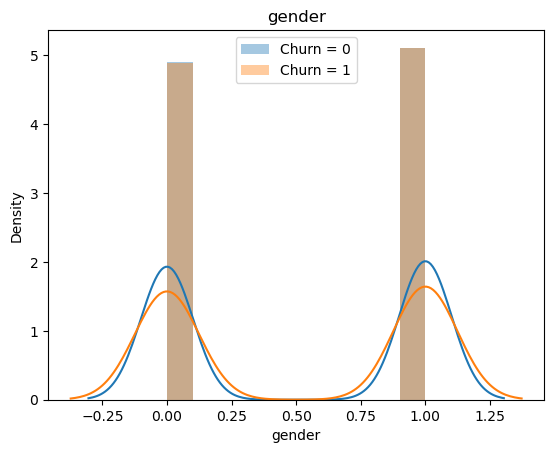

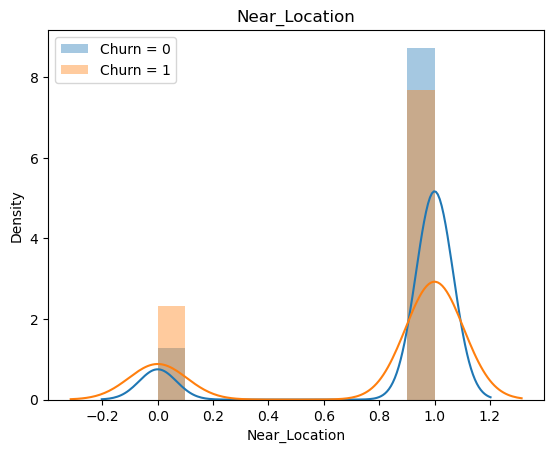

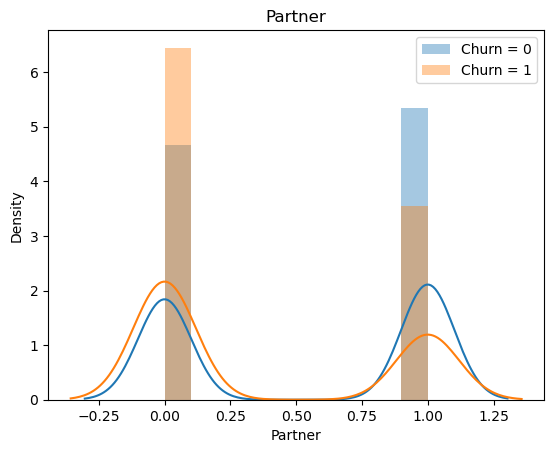

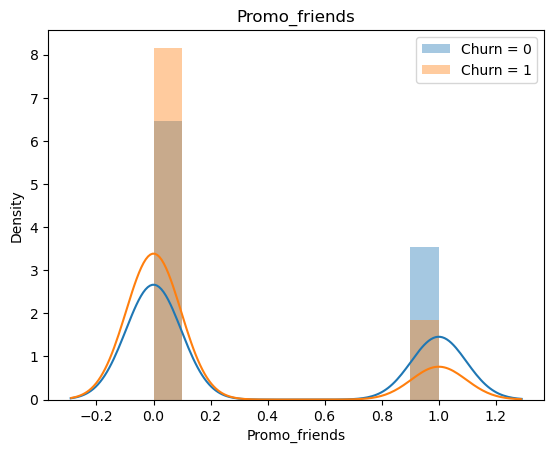

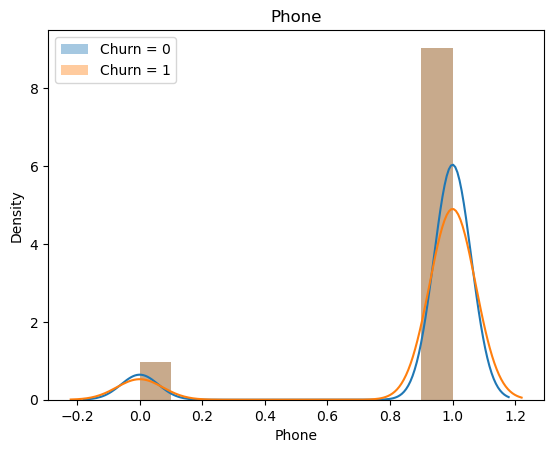

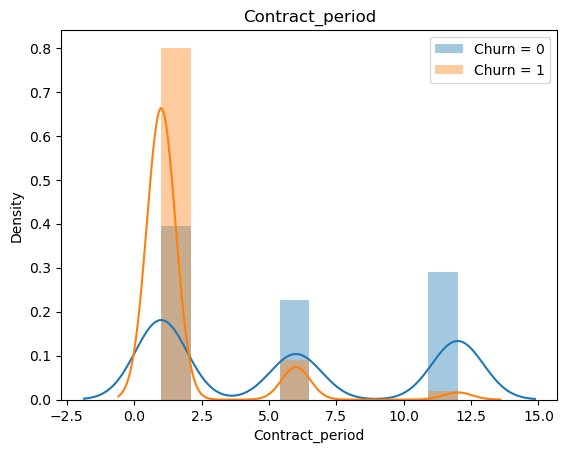

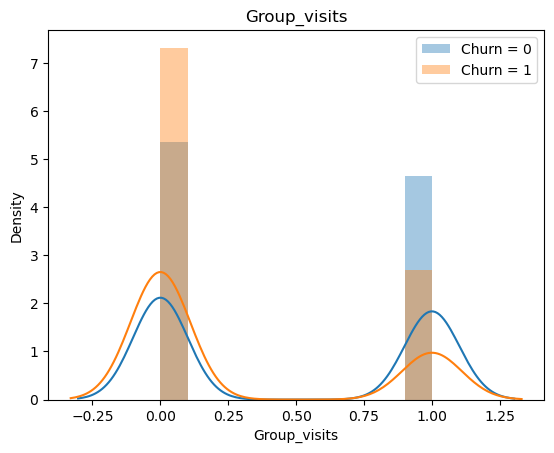

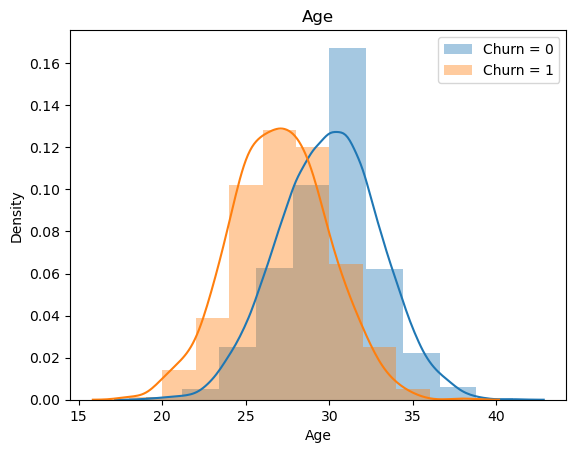

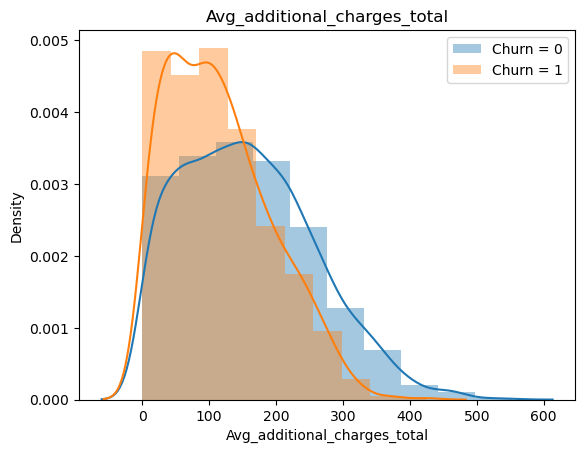

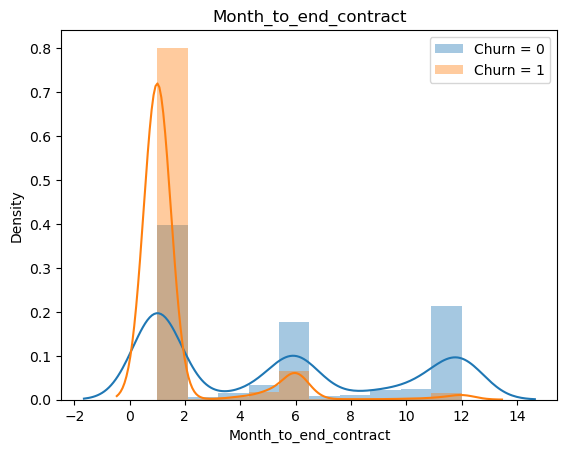

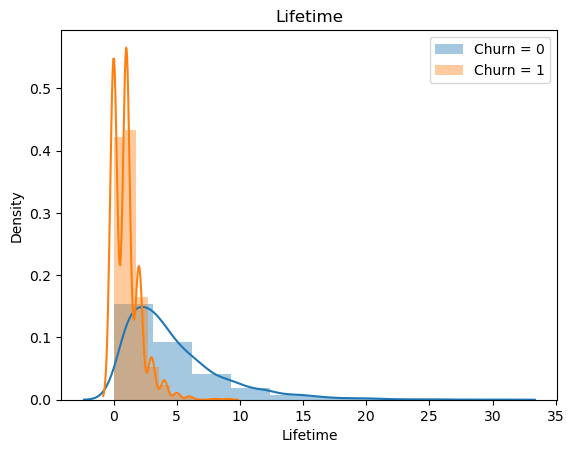

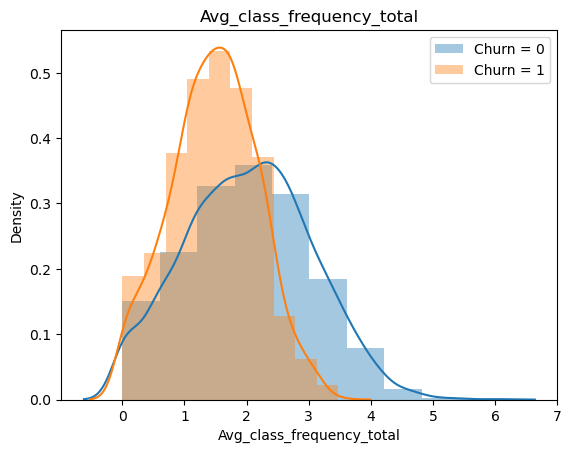

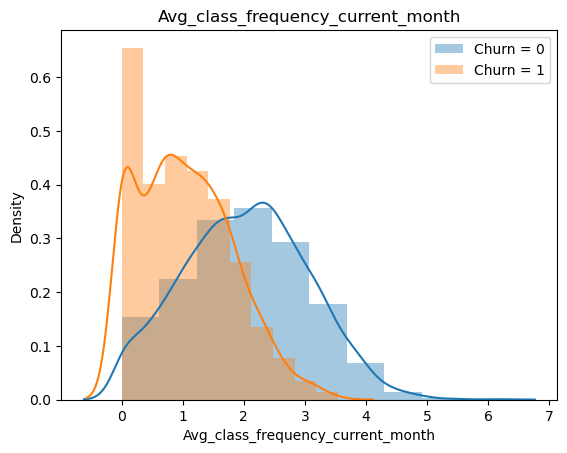

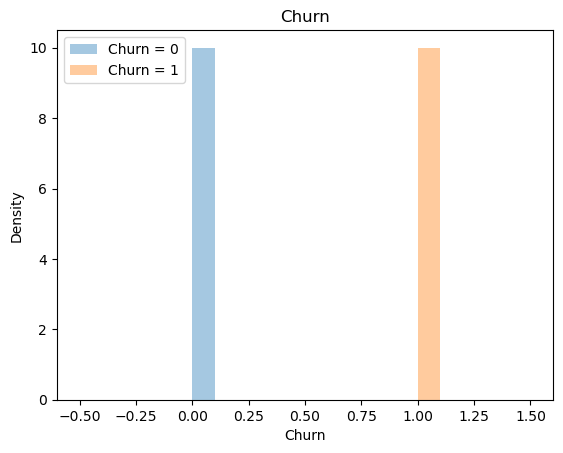

In [17]:
# %%
feat_hist(df, 'Churn', df.columns)


In [18]:
# %%
df.corr()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000000000000,0.006699227595081,-0.010462622250800,-0.005033272441054,-0.008542118064000,0.000502261220279,0.017878940218984,0.013806900920360,-0.009334436022097,-0.001280790522073,0.013578571154470,0.014620159193698,0.009156488375539,0.000707733985153
Near_Location,0.006699227595081,1.000000000000000,-0.005119431260763,0.210964279250089,-0.015763230257229,0.150232831416567,0.154728047973810,0.058357839446367,0.040761205686103,0.143960652863483,0.070920564055164,0.043127478605891,0.062663633458793,-0.128097990299810
Partner,-0.010462622250800,-0.005119431260763,1.000000000000000,0.451959803638693,0.009969610205313,0.306166251238889,0.022709566916954,0.047479698759628,0.022941185300935,0.294632124877685,0.061229353260985,0.024937869800103,0.045561091361999,-0.157985736985098
Promo_friends,-0.005033272441054,0.210964279250089,0.451959803638693,1.000000000000000,0.001981592231935,0.244551568070672,0.120169506269850,0.050113307413902,0.036897676000240,0.239553224750288,0.072721100932983,0.028063220773726,0.053768377063076,-0.162233077833515
Phone,-0.008542118064000,-0.015763230257229,0.009969610205313,0.001981592231935,1.000000000000000,-0.006893264000346,-0.010099146860770,-0.011403238953259,0.009279431489794,-0.011196256833938,-0.018801227382775,0.008340465501805,0.013374852916164,-0.001176601362480
Contract_period,0.000502261220279,0.150232831416567,0.306166251238889,0.244551568070672,-0.006893264000346,1.000000000000000,0.169990834019106,0.138249289429536,0.111445063341492,0.973063587268638,0.170725270972972,0.096211136398092,0.159407376566591,-0.389984211586078
Group_visits,0.017878940218984,0.154728047973810,0.022709566916954,0.120169506269850,-0.010099146860770,0.169990834019106,1.000000000000000,0.080933568901738,0.032079086460016,0.163702563158596,0.075852846038239,0.056694752430919,0.075923274727096,-0.175324655498149
Age,0.013806900920360,0.058357839446367,0.047479698759628,0.050113307413902,-0.011403238953259,0.138249289429536,0.080933568901738,1.000000000000000,0.080240125272997,0.134511341398497,0.164692820019427,0.119953132113990,0.183094542154536,-0.404735252823589
Avg_additional_charges_total,-0.009334436022097,0.040761205686103,0.022941185300935,0.036897676000240,0.009279431489794,0.111445063341492,0.032079086460016,0.080240125272997,1.000000000000000,0.113958039016871,0.079028338696600,0.044426412947373,0.079569677409450,-0.198697451068203
Month_to_end_contract,-0.001280790522073,0.143960652863483,0.294632124877685,0.239553224750288,-0.011196256833938,0.973063587268638,0.163702563158596,0.134511341398497,0.113958039016871,1.000000000000000,0.161077551415275,0.085386674018559,0.147605112323244,-0.381392983695714


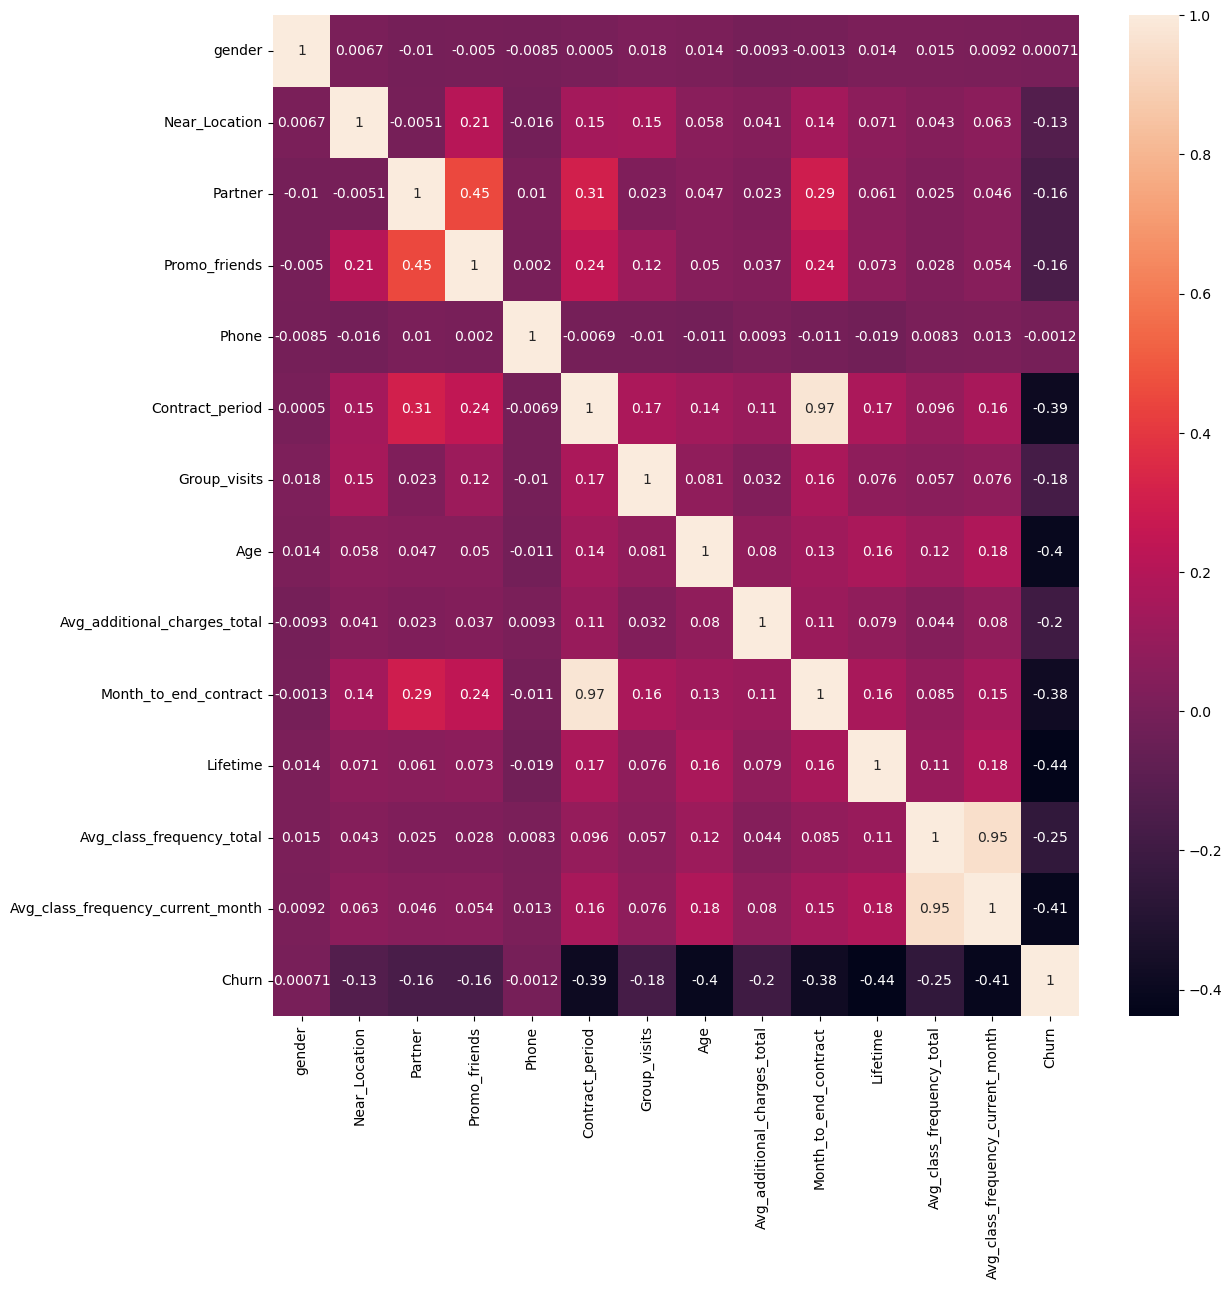

In [19]:
# %%
plt.figure(figsize = (13,13))
sns.heatmap(df.corr(), annot = True)
plt.show()


In [20]:
# %%



 ## Churn prediction

In [21]:
# %%
X_train, X_val, y_train, y_val = train_test_split(df.drop(columns = ['Churn']), df['Churn'], test_size = 0.2)


 Logistic Regression model:

In [22]:
# %%
lr_model = LogisticRegression()


In [23]:
# %%
lr_model.fit(X_train, y_train)


LogisticRegression()

In [24]:
# %%
y_proba_lr = lr_model.predict_proba(X_val)
y_pred_lr  = lr_model.predict(X_val)


In [25]:
# %%
print('Accuracy score for logistic regression is: {:.2f}'.format(accuracy_score(y_val, y_pred_lr)))
print('Precision score for logistic regression is: {:.2f}'.format(precision_score(y_val, y_pred_lr)))
print('Recall score for logistic regression is: {:.2f}'.format(recall_score(y_val, y_pred_lr)))


Accuracy score for logistic regression is: 0.91
Precision score for logistic regression is: 0.91
Recall score for logistic regression is: 0.77


 Random forest model:

In [26]:
# %%
rf_model = RandomForestClassifier(n_estimators=100)


In [27]:
# %%
rf_model.fit(X_train, y_train)


RandomForestClassifier()

In [28]:
# %%
y_proba_rf = rf_model.predict_proba(X_val)
y_pred_rf = rf_model.predict(X_val)


In [29]:
# %%
print('Accuracy score for random forest is: {:.2f}'.format(accuracy_score(y_val, y_pred_rf)))
print('Precision score for random forest is: {:.2f}'.format(precision_score(y_val, y_pred_rf)))
print('Recall score for random forest is: {:.2f}'.format(recall_score(y_val, y_pred_rf)))


Accuracy score for random forest is: 0.90
Precision score for random forest is: 0.87
Recall score for random forest is: 0.78


 Обе модели дают достаточно неплохие результаты. Доля правильных ответов у обеих моделей одинаковвая, а вот метрики точности и полноты немного лучше у логистической регрессии. Возможно, потому что случайгый лес слишком сильно переобучается. В любом случае для начала мы можем сделать выбор в пользу первой

In [30]:
# %%



 ## Clustering

In [31]:
# %%
sc = StandardScaler()
x_sc = sc.fit_transform(df.drop(columns = ['Churn']))


In [32]:
# %%
linked = linkage(x_sc, method = 'ward')


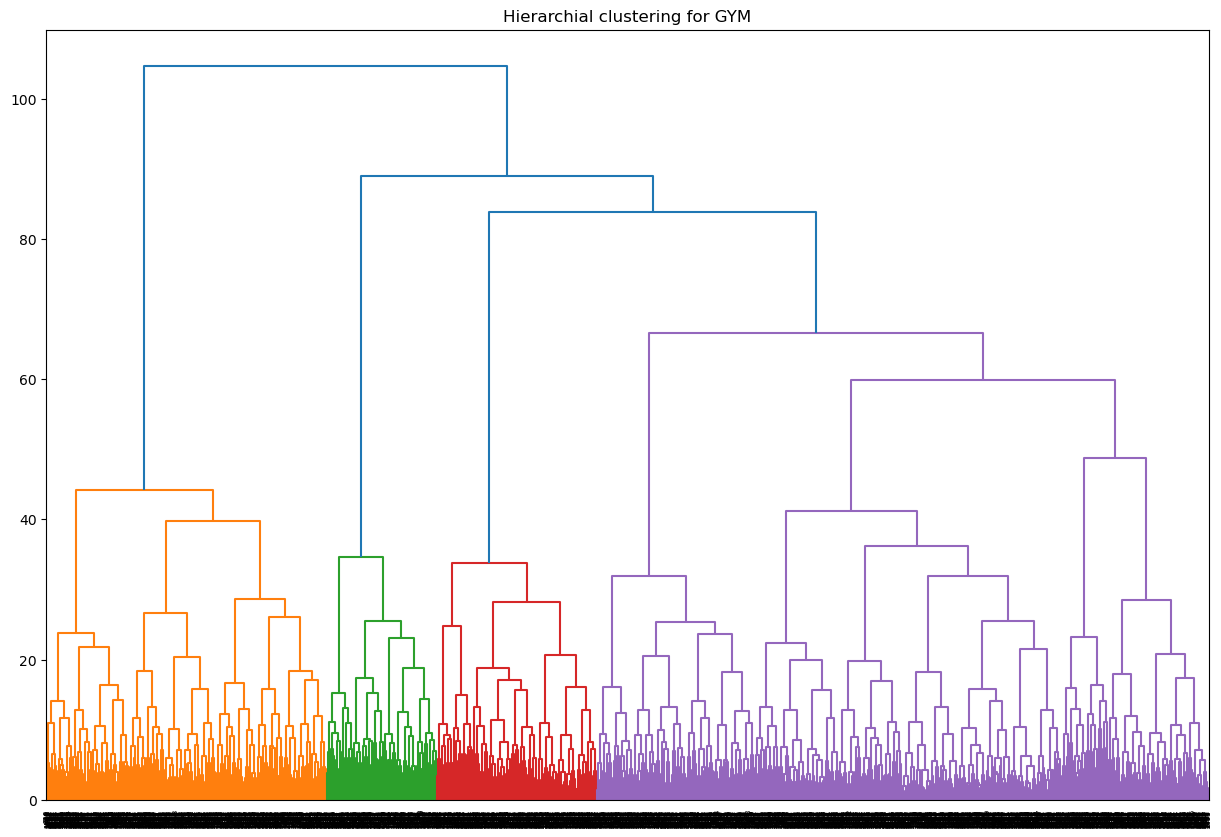

In [33]:
# %%
plt.figure(figsize=(15, 10))  
dendrogram(linked,
            orientation='top')
plt.title('Hierarchial clustering for GYM')
plt.show()


In [34]:
# %%
km = KMeans(n_clusters = 5)
labels = km.fit_predict(df.drop(columns = ['Churn']))


In [35]:
# %%
df['cluster_km'] = labels


In [38]:
##IRA
from sklearn.metrics import silhouette_score
print('Silhouette_score: {:.2f}'.format(silhouette_score(df, labels)))

Silhouette_score: 0.50


In [ ]:
# %%
df.groupby(['cluster_km']).count()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,1081,1081,1081,1081,1081,1081,1081,1081,1081,1081,1081,1081,1081,1081
1,951,951,951,951,951,951,951,951,951,951,951,951,951,951
2,672,672,672,672,672,672,672,672,672,672,672,672,672,672
3,1067,1067,1067,1067,1067,1067,1067,1067,1067,1067,1067,1067,1067,1067
4,229,229,229,229,229,229,229,229,229,229,229,229,229,229


In [ ]:
# %%
df.groupby(['cluster_km']).sum()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,552,892,529,314,977,4585,422,31259,40286.582635113649303,4209.0,3664,1984.884427711030412,1828.484217234431298,375
1,498,801,471,312,861,4587,403,27939,172212.183645210257964,4228.0,3590,1800.548702366902262,1700.010575359604672,210
2,351,594,346,234,608,3643,289,19725,173682.379464173136512,3366.0,2812,1297.033433098247542,1260.156528779267774,116
3,535,896,482,299,959,4545,432,30933,117933.963602707066457,4228.0,3818,1973.918678455976078,1821.579691328951185,352
4,105,198,119,75,209,1365,103,6881,83659.801889795955503,1260.0,1015,459.693608507589943,457.976275459775707,8


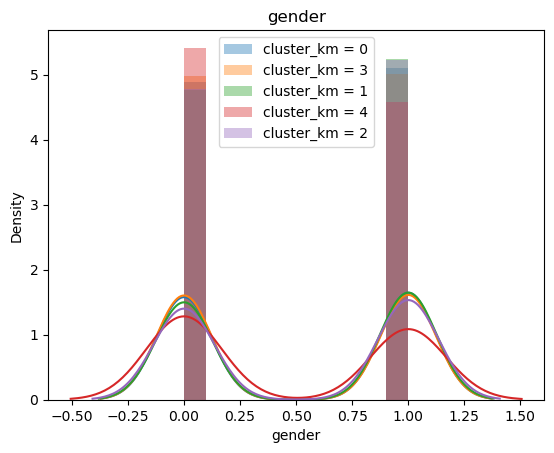

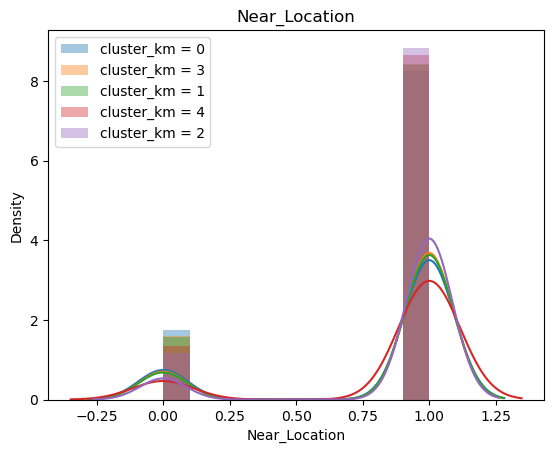

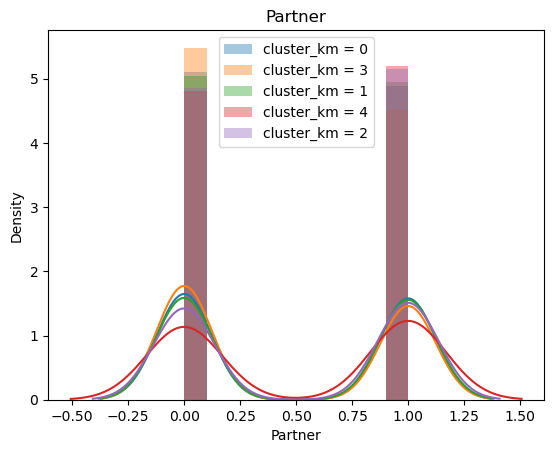

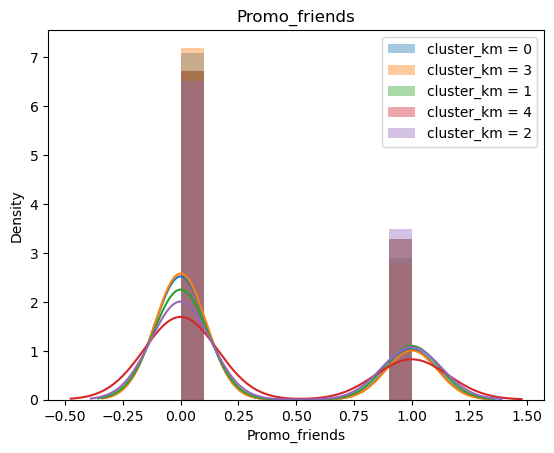

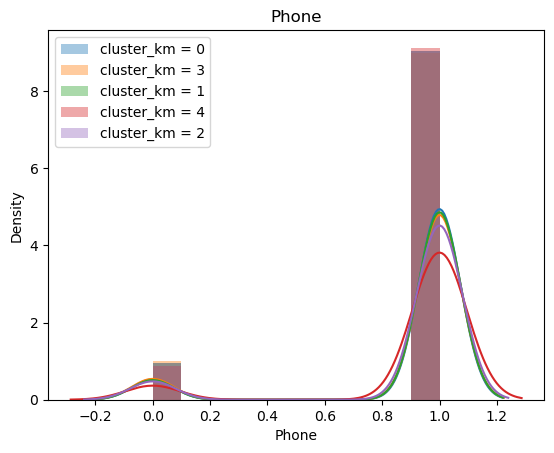

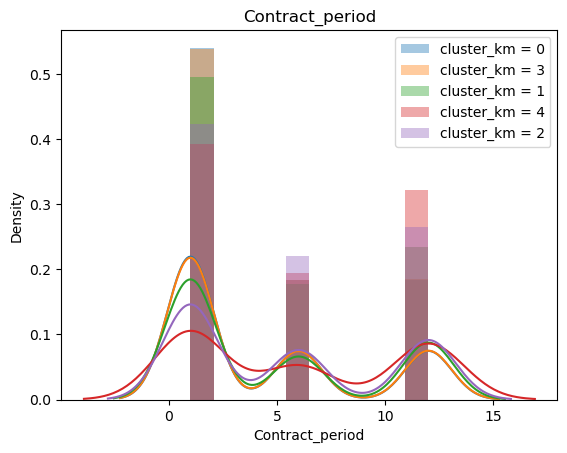

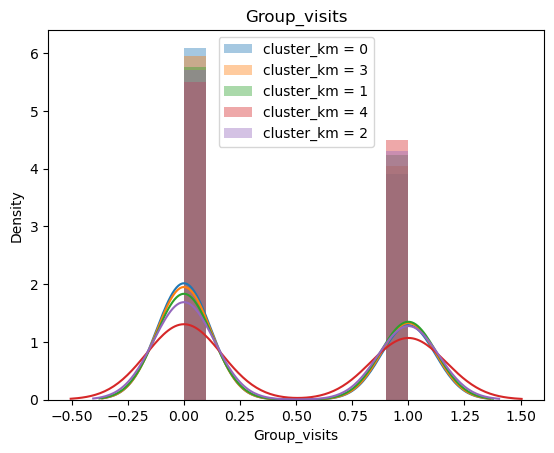

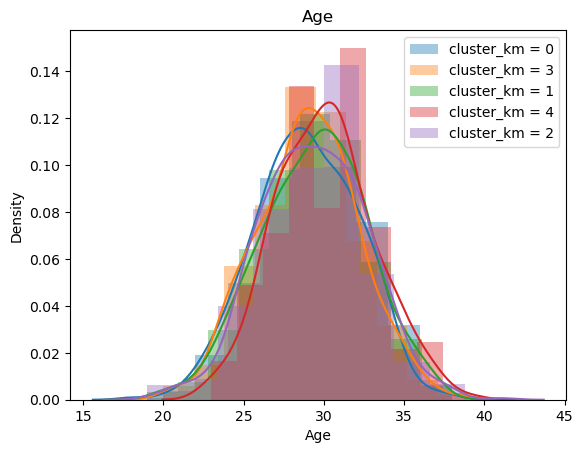

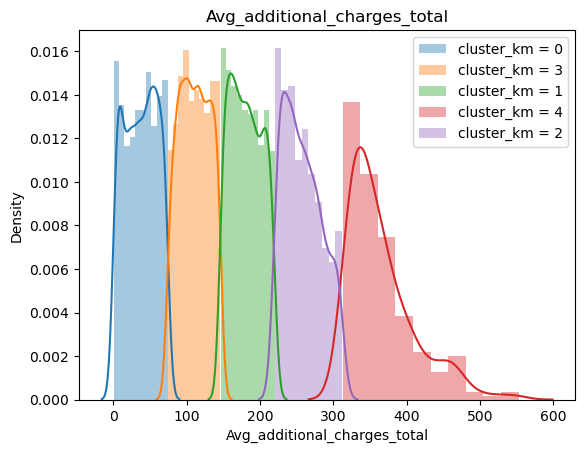

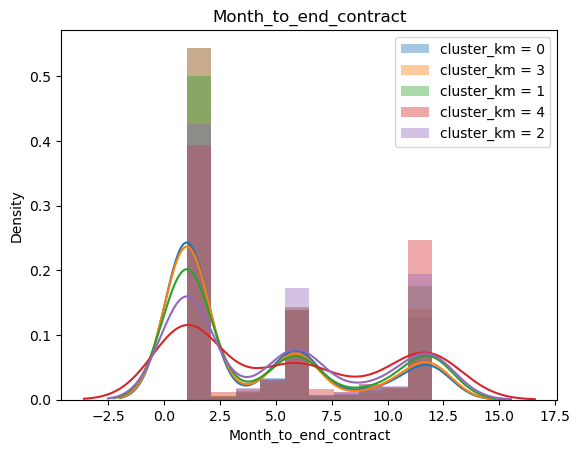

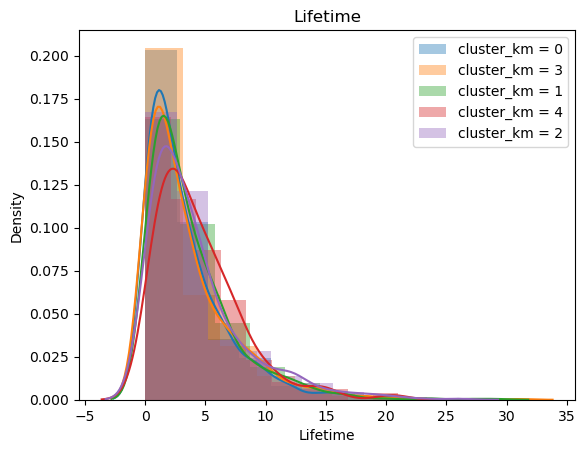

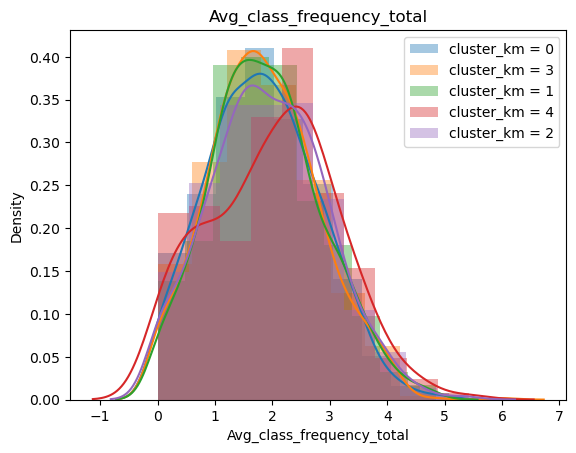

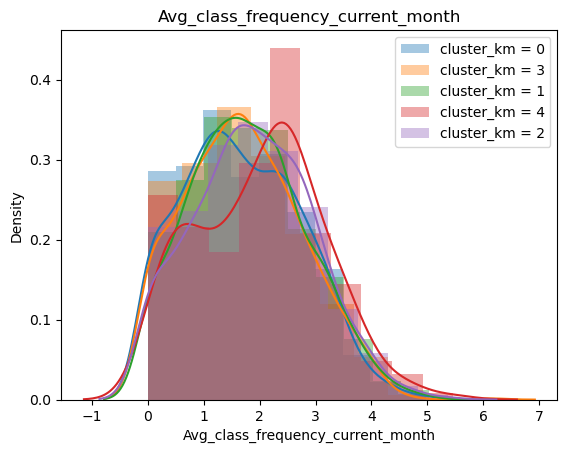

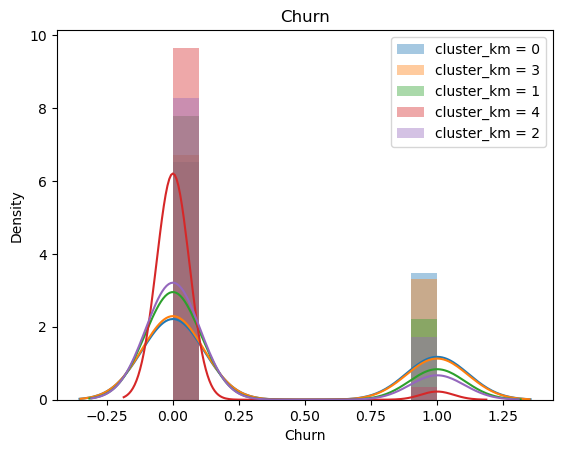

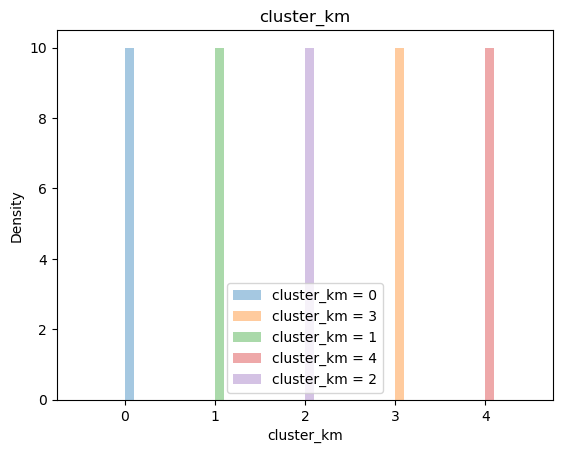

In [ ]:
# %%
feat_hist(df, 'cluster_km', df.columns)


In [ ]:
# %%
#посмотрим на долю оттока по кластерам
df.groupby(['cluster_km']).mean()['Churn']


cluster_km
0    0.346901017576318
1    0.220820189274448
2    0.172619047619048
3    0.329896907216495
4    0.034934497816594
Name: Churn, dtype: float64

 Самый отточный кластер - "2". Самые"надежные" клиенты - из кластеров "0" и "4"

In [ ]:
# %%

